# RQ1 

## Setup

* To replicate RQ1's evaluation use the default ```src/config.py``` values
* Follow the instructions on ```Readme.md```
* Inside the *pipeline* folder, run ```python -m src.main``` 
* Results are saved on ```results/RQ2```

## Results

In [ ]:
from src.config import *
from src.utils.efficiency import select_top_n_configs

top_configs = select_top_n_configs()

top_configs

Plotting top 10 most efficient configurations...
ℹ️ Using 'efficiency' as the efficiency metric.


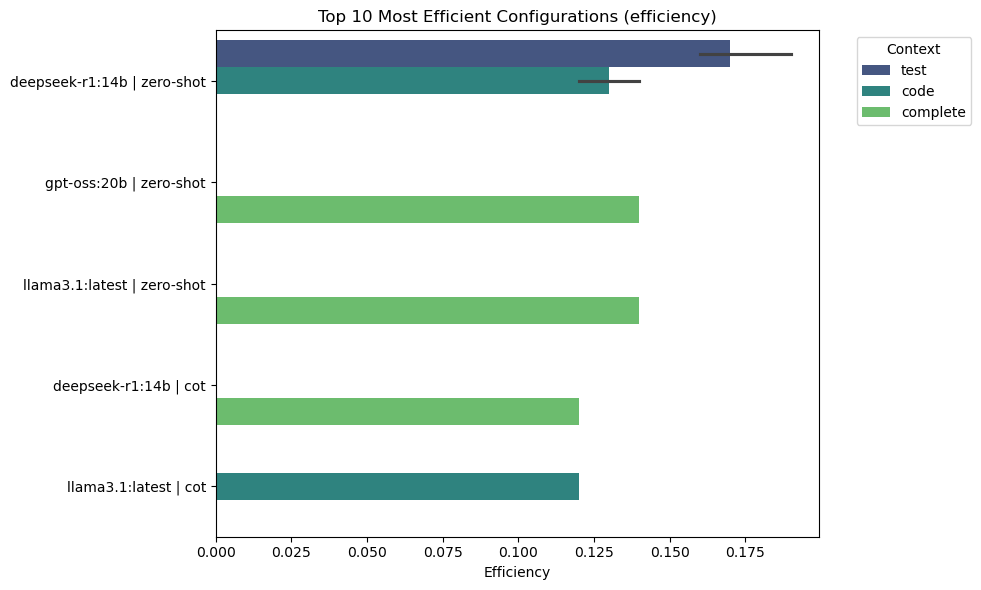

: 

In [ ]:
import os
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from src.config import *

TOP_N = 10  # explicitly set for clarity

def plot_top_efficient_combinations(n=TOP_N, metric=None):
    print(f"Plotting top {n} most efficient configurations...")

    if not os.path.exists(EFFICIENCY_PATH):
        raise FileNotFoundError(f"⚠️ Efficiency file not found at {EFFICIENCY_PATH}")

    df = pd.read_csv(EFFICIENCY_PATH)
    numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()

    if not numeric_cols:
        raise ValueError("No numeric columns found in the CSV.")

    # Automatically choose efficiency metric if not specified
    if metric is None:
        # Prefer a column that looks like an efficiency measure
        candidates = [c for c in numeric_cols if "efficiency" in c.lower()]
        metric = candidates[0] if candidates else numeric_cols[0]
        print(f" Using '{metric}' as the efficiency metric.")

    if metric not in df.columns:
        raise KeyError(f"Metric '{metric}' not found in CSV. Available columns: {list(df.columns)}")

    # Sort by efficiency metric (descending) and select top-N
    df_top = df.sort_values(by=metric, ascending=False).head(n)
    df_top["config"] = df_top["model"] + " | " + df_top["strategy"]

    # ---- Plot ----
    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=df_top,
        x=metric,
        y="config",
        hue="context",
        palette="viridis"
    )

    plt.title(f"Top {n} Most Efficient Configurations ({metric})")
    plt.xlabel(metric.replace("_", " ").title())
    plt.ylabel("")
    plt.legend(title="Context", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

    return df_top


if __name__ == "__main__":
    df_top = plot_top_efficient_combinations()
